In [1]:
#processed.csv generation
#SNR calculation
"""
PPG Signal Quality Assessment & Enhancement Pipeline (統合版)
既存の優れた前処理パイプラインにSNR計算機能を統合

【統合された手法の文献根拠】
前処理:
- Liang et al. (2018): Chebyshev Type II 4次フィルタが最適
  https://doi.org/10.1038/sdata.2018.76
- Allen & Murray (2004): 0.5-12 Hz推奨
  Physiological Measurement, 25(1), R1
- Park et al. (2022): PPG前処理の包括的レビュー
- Wang et al. (2007): Cubic spline baseline correction

品質評価:
- Reddy et al. (2022): 周波数ドメインSNR計算
  IEEE Access, 10, 20111-20127
- Mohagheghian et al. (2022): 信号品質指標の最適化
  IEEE Transactions on Biomedical Engineering, 69(10), 3982-3991
- Welch (1967): パワースペクトル推定の標準手法
"""

import pandas as pd
import numpy as np
from scipy import signal
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import median_filter, minimum_filter
import logging
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ログ設定
log_filename = f"ppg_quality_assessment_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename, encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


class PPGQualityAssessor:
    """
    PPG信号品質評価クラス
    
    文献根拠:
    - Welch法によるパワースペクトル推定 (Welch, 1967)
    - 周波数ドメインSNR (Reddy et al., 2022)
    - Perfusion Index計算 (標準的な臨床指標)
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        
    def calculate_snr_welch(self, signal_data, signal_band=(0.5, 4.0), noise_band=(4.0, 15.0)):
        """
        Welch法によるSNR計算
        
        文献根拠:
        - Welch (1967): 安定したパワースペクトル推定
        - Reddy et al. (2022): 周波数ドメインSNR評価
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
        signal_band : tuple
            信号帯域 (Hz) - 心拍成分
        noise_band : tuple
            ノイズ帯域 (Hz)
            
        Returns:
        --------
        snr_db : float
            SNR [dB]
        signal_power : float
            信号パワー
        noise_power : float
            ノイズパワー
        """
        try:
            # Welch法でパワースペクトル密度を推定
            nperseg = min(len(signal_data), 2048)
            freqs, psd = signal.welch(
                signal_data, 
                fs=self.fs, 
                nperseg=nperseg,
                noverlap=nperseg//2,
                scaling='density'
            )
            
            # 信号帯域のパワー
            signal_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
            signal_power = np.trapz(psd[signal_mask], freqs[signal_mask])
            
            # ノイズ帯域のパワー
            noise_mask = (freqs >= noise_band[0]) & (freqs <= noise_band[1])
            noise_power = np.trapz(psd[noise_mask], freqs[noise_mask])
            
            # SNR計算
            if noise_power > 1e-10:
                snr_db = 10 * np.log10(signal_power / noise_power)
            else:
                snr_db = np.inf
                logger.warning("Noise power near zero, SNR set to infinity")
            
            return snr_db, signal_power, noise_power
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_welch: {str(e)}")
            return np.nan, np.nan, np.nan
    
    def calculate_snr_fft(self, signal_data, signal_band=(0.5, 4.0), noise_band=(4.0, 15.0)):
        """
        FFTベースのSNR計算（高速版）
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
        signal_band : tuple
            信号帯域 (Hz)
        noise_band : tuple
            ノイズ帯域 (Hz)
            
        Returns:
        --------
        snr_db : float
            SNR [dB]
        """
        try:
            n = len(signal_data)
            sig_detrend = signal_data - np.mean(signal_data)
            
            # FFT
            yf = fft(sig_detrend)
            xf = fftfreq(n, 1/self.fs)
            
            # パワースペクトル
            psd = np.abs(yf)**2 / n
            
            # 信号帯域
            sig_mask = (xf >= signal_band[0]) & (xf <= signal_band[1])
            p_signal = np.sum(psd[sig_mask])
            
            # ノイズ帯域
            noise_mask = (xf >= noise_band[0]) & (xf <= noise_band[1])
            p_noise = np.sum(psd[noise_mask])
            
            if p_noise > 0:
                snr_db = 10 * np.log10(p_signal / p_noise)
            else:
                snr_db = np.inf
            
            return snr_db
            
        except Exception as e:
            logger.error(f"Error in calculate_snr_fft: {str(e)}")
            return np.nan
    
    def calculate_perfusion_index(self, signal_data):
        """
        Perfusion Index (PI) 計算
        
        PI = (AC / DC) × 100 [%]
        
        文献根拠: 臨床的PPG品質評価の標準指標
        
        Parameters:
        -----------
        signal_data : array-like
            入力信号
            
        Returns:
        --------
        pi_percent : float
            Perfusion Index [%]
        dc_component : float
            DC成分
        ac_component : float
            AC成分 (RMS)
        """
        try:
            # DC成分（平均値）
            dc_component = np.mean(signal_data)
            
            # AC成分（標準偏差 or RMS）
            ac_component = np.std(signal_data)
            
            # PI計算
            if abs(dc_component) > 1e-6:
                pi_percent = (ac_component / abs(dc_component)) * 100
            else:
                pi_percent = np.nan
            
            return pi_percent, dc_component, ac_component
            
        except Exception as e:
            logger.error(f"Error in calculate_perfusion_index: {str(e)}")
            return np.nan, np.nan, np.nan
    
    def calculate_statistical_features(self, signal_data):
        """
        統計的特徴量の計算
        
        文献根拠:
        - Mohagheghian et al. (2022): 特徴量ベースの信号品質評価
        
        Returns:
        --------
        features : dict
            統計的特徴量
        """
        try:
            features = {
                'mean': float(np.mean(signal_data)),
                'std': float(np.std(signal_data)),
                'skewness': float(skew(signal_data)),
                'kurtosis': float(kurtosis(signal_data)),
                'peak_to_peak': float(np.max(signal_data) - np.min(signal_data)),
                'cv': float(np.std(signal_data) / (abs(np.mean(signal_data)) + 1e-10)),
                'rms': float(np.sqrt(np.mean(signal_data**2)))
            }
            return features
            
        except Exception as e:
            logger.error(f"Error in calculate_statistical_features: {str(e)}")
            return {}
    
    def comprehensive_quality_assessment(self, signal_data):
        """
        包括的品質評価
        
        Returns:
        --------
        quality_metrics : dict
            全品質指標
        """
        try:
            quality_metrics = {}
            
            # SNR計算（Welch法 - より安定）
            snr_welch, sig_power, noise_power = self.calculate_snr_welch(signal_data)
            quality_metrics['SNR_Welch_dB'] = snr_welch
            quality_metrics['Signal_Power'] = sig_power
            quality_metrics['Noise_Power'] = noise_power
            
            # SNR計算（FFT法 - 比較用）
            snr_fft = self.calculate_snr_fft(signal_data)
            quality_metrics['SNR_FFT_dB'] = snr_fft
            
            # Perfusion Index
            pi, dc, ac = self.calculate_perfusion_index(signal_data)
            quality_metrics['PI_Percent'] = pi
            quality_metrics['DC_Component'] = dc
            quality_metrics['AC_Component'] = ac
            
            # 統計的特徴
            stat_features = self.calculate_statistical_features(signal_data)
            quality_metrics.update(stat_features)
            
            return quality_metrics
            
        except Exception as e:
            logger.error(f"Error in comprehensive_quality_assessment: {str(e)}")
            return {}


class PPGPreprocessor:
    """
    PPG信号前処理クラス（既存コードベース）
    文献ベースの最適な手法を実装
    """
    
    def __init__(self, fs=2000.0):
        self.fs = fs
        logger.info(f"PPGPreprocessor initialized with fs={fs} Hz")
        
    def bandpass_filter(self, signal_data, low_cut=0.5, high_cut=10.0, order=4):
        """
        Chebyshev Type II バンドパスフィルタ
        
        文献根拠:
        - Liang et al. (2018): 4th-order Chebyshev Type-II filter が最適
        """
        try:
            nyq = 0.5 * self.fs
            low = low_cut / nyq
            high = high_cut / nyq
            
            sos = signal.cheby2(order, rs=40, Wn=[low, high], btype='band', output='sos')
            filtered_signal = signal.sosfiltfilt(sos, signal_data)
            
            return filtered_signal
            
        except Exception as e:
            logger.error(f"Error in bandpass_filter: {str(e)}")
            return signal_data
    
    def detect_artifacts_mad(self, signal_data, threshold=3.5):
        """
        MAD (Median Absolute Deviation) ベースのアーティファクト検出
        
        文献根拠:
        - Leys et al. (2013): MADは外れ値検出に対してロバスト
        """
        try:
            median = np.median(signal_data)
            mad = np.median(np.abs(signal_data - median))
            
            if mad == 0:
                std = np.std(signal_data)
                artifact_mask = np.abs(signal_data - np.mean(signal_data)) > threshold * std
            else:
                modified_z_scores = 0.6745 * (signal_data - median) / mad
                artifact_mask = np.abs(modified_z_scores) > threshold
            
            return artifact_mask
            
        except Exception as e:
            logger.error(f"Error in detect_artifacts_mad: {str(e)}")
            return np.zeros(len(signal_data), dtype=bool)
    
    def remove_artifacts(self, signal_data, artifact_mask, method='interpolation'):
        """
        アーティファクト除去
        """
        try:
            cleaned_signal = signal_data.copy()
            
            if method == 'interpolation':
                valid_indices = np.where(~artifact_mask)[0]
                artifact_indices = np.where(artifact_mask)[0]
                
                if len(valid_indices) > 1 and len(artifact_indices) > 0:
                    cleaned_signal[artifact_indices] = np.interp(
                        artifact_indices,
                        valid_indices,
                        signal_data[valid_indices]
                    )
            
            elif method == 'median':
                kernel_size = int(self.fs * 0.1)
                if kernel_size % 2 == 0:
                    kernel_size += 1
                cleaned_signal[artifact_mask] = median_filter(signal_data, size=kernel_size)[artifact_mask]
            
            return cleaned_signal
            
        except Exception as e:
            logger.error(f"Error in remove_artifacts: {str(e)}")
            return signal_data
    
    def baseline_correction_spline(self, signal_data, smoothness=0.01):
        """
        Cubic Spline補間によるベースライン補正
        
        文献根拠:
        - Wang et al. (2007): Cubic spline interpolationが効果的
        """
        try:
            x = np.arange(len(signal_data))
            
            window_size = int(self.fs * 0.8)
            if window_size % 2 == 0:
                window_size += 1
            
            baseline_estimate = minimum_filter(signal_data, size=window_size, mode='nearest')
            
            s_param = smoothness * len(signal_data)
            spline = UnivariateSpline(x, baseline_estimate, s=s_param, k=3)
            baseline = spline(x)
            
            corrected_signal = signal_data - baseline
            
            return corrected_signal
            
        except Exception as e:
            logger.error(f"Error in baseline_correction_spline: {str(e)}")
            return signal_data
    
    def full_preprocessing_pipeline(self, signal_data, 
                                   bandpass_params={'low_cut': 0.5, 'high_cut': 10.0, 'order': 4},
                                   artifact_params={'threshold': 3.5, 'method': 'interpolation'},
                                   baseline_params={'method': 'spline', 'smoothness': 0.01}):
        """
        完全な前処理パイプライン
        
        処理順序:
        1. Bandpass filtering
        2. Artifact detection & removal
        3. Baseline correction
        """
        try:
            logger.debug("Starting full preprocessing pipeline")
            processing_info = {}
            
            # 入力統計
            processing_info['input_stats'] = {
                'length': len(signal_data),
                'mean': float(np.mean(signal_data)),
                'std': float(np.std(signal_data))
            }
            
            # Step 1: Bandpass filtering
            filtered_signal = self.bandpass_filter(signal_data, **bandpass_params)
            
            # Step 2: Artifact detection & removal
            artifact_mask = self.detect_artifacts_mad(filtered_signal, threshold=artifact_params['threshold'])
            artifact_removed_signal = self.remove_artifacts(filtered_signal, artifact_mask, method=artifact_params['method'])
            
            processing_info['artifacts'] = {
                'count': int(np.sum(artifact_mask)),
                'percentage': float((np.sum(artifact_mask) / len(signal_data)) * 100)
            }
            
            # Step 3: Baseline correction
            if baseline_params['method'] == 'spline':
                processed_signal = self.baseline_correction_spline(
                    artifact_removed_signal, 
                    smoothness=baseline_params['smoothness']
                )
            else:
                processed_signal = artifact_removed_signal
            
            # 出力統計
            processing_info['output_stats'] = {
                'mean': float(np.mean(processed_signal)),
                'std': float(np.std(processed_signal))
            }
            
            return processed_signal, processing_info
            
        except Exception as e:
            logger.error(f"Error in full_preprocessing_pipeline: {str(e)}")
            return signal_data, {}


def process_all_files_with_quality_assessment():
    """
    全ファイルの処理 + 品質評価（統合版メイン関数）
    """
    logger.info("="*80)
    logger.info("PPG Signal Quality Assessment & Enhancement Pipeline")
    logger.info("前処理 + 品質評価の統合処理")
    logger.info("="*80)
    
    # パラメータ設定
    depths = [3, 9, 15, 21]
    state_map = {1: "Normal", 2: "Ischaemia", 3: "Congestion"}
    channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"}
    
    # 初期化
    preprocessor = PPGPreprocessor(fs=2000.0)
    quality_assessor = PPGQualityAssessor(fs=2000.0)
    
    # 品質評価結果を保存
    quality_records = []
    
    # 統計
    total_files = 0
    successful_files = 0
    
    # 全ファイルを処理
    for depth in depths:
        for i_state, state_name in state_map.items():
            total_files += 1
            
            input_filename = f"{depth}mm_adjusted_data{i_state}.csv"
            output_filename = f"{depth}mm_processed_data{i_state}.csv"
            
            logger.info("-" * 80)
            logger.info(f"Processing: {input_filename} (Depth: {depth}mm, State: {state_name})")
            logger.info("-" * 80)
            
            try:
                if not os.path.exists(input_filename):
                    logger.error(f"File not found: {input_filename}")
                    continue
                
                df = pd.read_csv(input_filename)
                logger.info(f"Loaded: {input_filename} ({len(df)} rows)")
                
                # 各チャンネルを処理
                for channel_name, column_name in channels.items():
                    logger.info(f"  Channel: {channel_name}")
                    
                    if column_name not in df.columns:
                        logger.error(f"Column '{column_name}' not found")
                        continue
                    
                    # 生信号
                    raw_signal = df[column_name].values
                    
                    # NaN/Inf処理
                    if np.any(np.isnan(raw_signal)) or np.any(np.isinf(raw_signal)):
                        raw_signal = np.nan_to_num(raw_signal, nan=np.nanmedian(raw_signal))
                    
                    # === 前処理前の品質評価 ===
                    raw_quality = quality_assessor.comprehensive_quality_assessment(raw_signal)
                    logger.info(f"    Raw SNR (Welch): {raw_quality['SNR_Welch_dB']:.2f} dB")
                    logger.info(f"    Raw PI: {raw_quality['PI_Percent']:.4f} %")
                    
                    # 品質記録
                    record_raw = {
                        'Depth_mm': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'Processing': 'Raw'
                    }
                    record_raw.update(raw_quality)
                    quality_records.append(record_raw)
                    
                    # === 前処理実行 ===
                    processed_signal, processing_info = preprocessor.full_preprocessing_pipeline(
                        raw_signal,
                        bandpass_params={'low_cut': 0.5, 'high_cut': 10.0, 'order': 4},
                        artifact_params={'threshold': 3.5, 'method': 'interpolation'},
                        baseline_params={'method': 'spline', 'smoothness': 0.01}
                    )
                    
                    # === 前処理後の品質評価 ===
                    processed_quality = quality_assessor.comprehensive_quality_assessment(processed_signal)
                    snr_improvement = processed_quality['SNR_Welch_dB'] - raw_quality['SNR_Welch_dB']
                    
                    logger.info(f"    Processed SNR (Welch): {processed_quality['SNR_Welch_dB']:.2f} dB")
                    logger.info(f"    Processed PI: {processed_quality['PI_Percent']:.4f} %")
                    logger.info(f"    ✓ SNR Improvement: {snr_improvement:+.2f} dB")
                    logger.info(f"    Artifacts removed: {processing_info['artifacts']['count']} ({processing_info['artifacts']['percentage']:.2f}%)")
                    
                    # 品質記録
                    record_processed = {
                        'Depth_mm': depth,
                        'State': state_name,
                        'Channel': channel_name,
                        'Processing': 'Processed'
                    }
                    record_processed.update(processed_quality)
                    record_processed['SNR_Improvement_dB'] = snr_improvement
                    record_processed['Artifacts_Count'] = processing_info['artifacts']['count']
                    record_processed['Artifacts_Percent'] = processing_info['artifacts']['percentage']
                    quality_records.append(record_processed)
                    
                    # 前処理済み信号を保存
                    new_column_name = f"{channel_name}_processed"
                    df[new_column_name] = processed_signal
                
                # CSV保存
                df.to_csv(output_filename, index=False)
                logger.info(f"✓ Saved: {output_filename}")
                successful_files += 1
                
            except Exception as e:
                logger.error(f"✗ Failed: {input_filename}")
                logger.exception(f"Error: {str(e)}")
    
    # === 品質評価サマリーの保存 ===
    if quality_records:
        df_quality = pd.DataFrame(quality_records)
        quality_summary_file = "PPG_Quality_Assessment_Summary.csv"
        df_quality.to_csv(quality_summary_file, index=False)
        logger.info(f"\n✅ Quality assessment saved: {quality_summary_file}")
        
        # 統計サマリー
        logger.info("\n" + "="*80)
        logger.info("QUALITY ASSESSMENT SUMMARY")
        logger.info("="*80)
        
        for proc_type in ['Raw', 'Processed']:
            subset = df_quality[df_quality['Processing'] == proc_type]
            if len(subset) > 0:
                snr_vals = subset['SNR_Welch_dB'].replace([np.inf, -np.inf], np.nan).dropna()
                pi_vals = subset['PI_Percent'].replace([np.inf, -np.inf], np.nan).dropna()
                
                logger.info(f"\n{proc_type} Signal Quality:")
                if len(snr_vals) > 0:
                    logger.info(f"  SNR (Welch): {snr_vals.mean():.2f} ± {snr_vals.std():.2f} dB")
                    logger.info(f"  SNR Range: [{snr_vals.min():.2f}, {snr_vals.max():.2f}] dB")
                if len(pi_vals) > 0:
                    logger.info(f"  PI: {pi_vals.mean():.4f} ± {pi_vals.std():.4f} %")
        
        # SNR改善度の分析
        processed_subset = df_quality[df_quality['Processing'] == 'Processed']
        if 'SNR_Improvement_dB' in processed_subset.columns:
            improvements = processed_subset['SNR_Improvement_dB'].replace([np.inf, -np.inf], np.nan).dropna()
            if len(improvements) > 0:
                logger.info(f"\nSNR Improvement Statistics:")
                logger.info(f"  Mean: {improvements.mean():.2f} dB")
                logger.info(f"  Median: {improvements.median():.2f} dB")
                logger.info(f"  Range: [{improvements.min():.2f}, {improvements.max():.2f}] dB")
    
    # 処理サマリー
    logger.info("\n" + "="*80)
    logger.info("PROCESSING SUMMARY")
    logger.info("="*80)
    logger.info(f"Total files: {total_files}")
    logger.info(f"Successful: {successful_files}")
    logger.info(f"Success rate: {(successful_files/total_files)*100:.1f}%")
    logger.info(f"Log file: {log_filename}")
    logger.info("="*80)


if __name__ == "__main__":
    process_all_files_with_quality_assessment()

2026-05-07 15:50:22,836 - INFO - ================================================================================
2026-05-07 15:50:22,840 - INFO - PPG Signal Quality Assessment & Enhancement Pipeline
2026-05-07 15:50:22,841 - INFO - 前処理 + 品質評価の統合処理
2026-05-07 15:50:22,850 - INFO - ================================================================================
2026-05-07 15:50:22,870 - INFO - PPGPreprocessor initialized with fs=2000.0 Hz
2026-05-07 15:50:22,872 - INFO - --------------------------------------------------------------------------------
2026-05-07 15:50:22,872 - INFO - Processing: 3mm_adjusted_data1.csv (Depth: 3mm, State: Normal)
2026-05-07 15:50:22,887 - INFO - --------------------------------------------------------------------------------
2026-05-07 15:50:23,006 - INFO - Loaded: 3mm_adjusted_data1.csv (61200 rows)
2026-05-07 15:50:23,007 - INFO -   Channel: Red
2026-05-07 15:50:23,047 - INFO -     Raw SNR (Welch): 15.33 dB
2026-05-07 15:50:23,048 - INFO -     Raw PI: 0

2026-05-07 15:50:36,693 - INFO - maxp pruned
2026-05-07 15:50:36,695 - INFO - LTSH dropped
2026-05-07 15:50:36,696 - INFO - cmap pruned
2026-05-07 15:50:36,697 - INFO - kern dropped
2026-05-07 15:50:36,700 - INFO - post pruned
2026-05-07 15:50:36,700 - INFO - PCLT dropped
2026-05-07 15:50:36,700 - INFO - JSTF dropped
2026-05-07 15:50:36,701 - INFO - DSIG dropped
2026-05-07 15:50:36,703 - INFO - GPOS pruned
2026-05-07 15:50:36,704 - INFO - GSUB pruned
2026-05-07 15:50:36,708 - INFO - glyf pruned
2026-05-07 15:50:36,710 - INFO - Added gid0 to subset
2026-05-07 15:50:36,710 - INFO - Added first four glyphs to subset
2026-05-07 15:50:36,710 - INFO - Closing glyph list over 'GSUB': 38 glyphs before
2026-05-07 15:50:36,711 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'I', 'N', 'R', 'T', 'a', 'c', 'd', 'e', 'five', 'four', 'g', 'h', 'i', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'three', 'tw

✅ 図を保存しました:
  - PPG_waveform_comparison.tiff (600 dpi)
  - PPG_waveform_comparison.pdf (ベクター)
  - PPG_waveform_comparison.eps (ベクター)


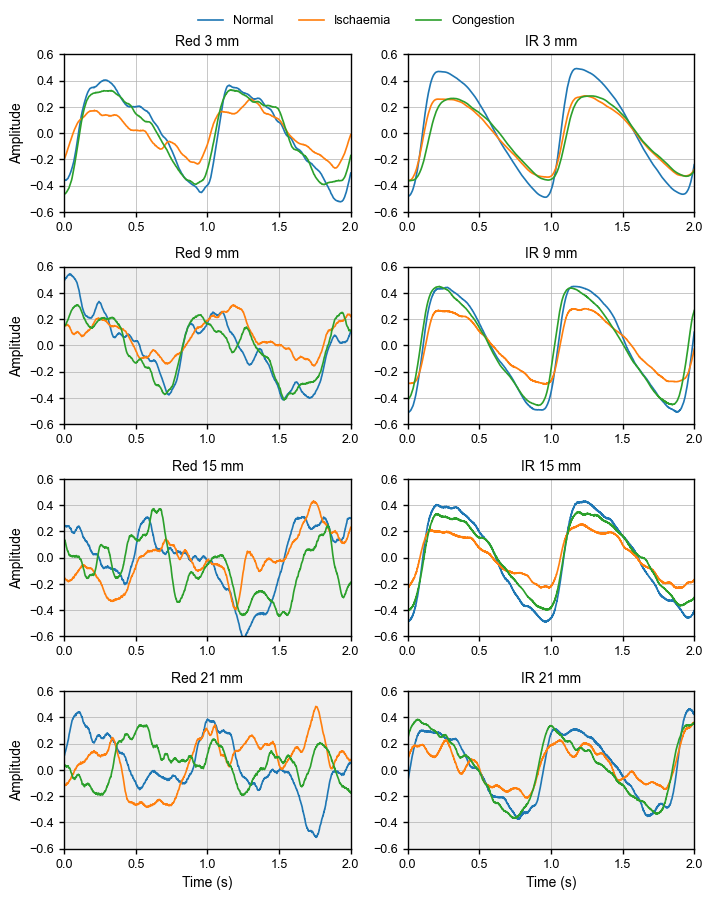

In [2]:
#waveform visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter
import matplotlib.ticker as ticker
import math

# ========= パラメータ設定 =========
fs = 2000  # サンプリングレート [Hz]
start_time = 15.0    # 基本の表示開始時間 [秒]
display_time = 2.0   # 表示時間 [秒]
OFFSET_SAMPLES = 500 # MA安定化のためのオフセット点数 (0.25s)
OFFSET_TIME = OFFSET_SAMPLES / fs  

depths = [3, 9, 15, 21]
states = ["Normal", "Ischaemia", "Congestion"]
legend_labels = ['Normal', 'Ischaemia', 'Congestion']
channels = {"Red": "ppgA_Red_raw", "IR": "ppgA_IR_raw"} 

# --- フィルタリング＆スムージング設定 ---
BSF_LOW_CUT = 20.0  
BSF_HIGH_CUT = 50.0 
BSF_ORDER = 4       
MA_WINDOW = 200     
SG_WINDOW = 51 
SG_POLY = 3

# --- 手動ピーク位置合わせ設定（★修正: IR 9mm, 15mm の全状態に+0.75s, +0.4s適用） ---
manual_start_offsets_s = {
    3: {"Red": {"Normal": 0.0, "Ischaemia": 0.35, "Congestion": 0.7}, 
        "IR": {"Normal": 0.0, "Ischaemia": -0.7, "Congestion": -0.3}},
    9: {"Red": {"Normal": 0.2, "Ischaemia": 0.0, "Congestion": 0.0}, 
        "IR": {"Normal": 0.75, "Ischaemia": 0.75, "Congestion": 0.75 + 0.2}},  # ★全状態に+0.75s
    15: {"Red": {"Normal": 0.0, "Ischaemia": 0.5, "Congestion": 0.1}, 
         "IR": {"Normal": 0.4, "Ischaemia": 0.4 - 0.5, "Congestion": 0.4 + 0.03}},  # ★全状態に+0.4s
    21: {"Red": {"Normal": 0.0, "Ischaemia": 0.35, "Congestion": 0.0}, 
         "IR": {"Normal": 0.0, "Ischaemia": 0.2, "Congestion": 0.4}},
}

# ========= Sci Rep準拠の設定 =========
# フォント設定（Arial推奨、8-12 pt）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 9  # 基本フォントサイズ
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# 線幅設定（最低1 pt以上）
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

# PDF出力設定
plt.rcParams['pdf.fonttype'] = 42  # TrueType埋め込み
plt.rcParams['ps.fonttype'] = 42

def calculate_amplitude(signal):
    """信号のPeak-to-Peak振幅を計算 (Max - Min)"""
    return np.max(signal) - np.min(signal)

def bandstop_filter_noise_reduction(sig, fs, low_cutoff, high_cutoff, order=BSF_ORDER):
    nyq = fs / 2
    b, a = butter(order, [low_cutoff / nyq, high_cutoff / nyq], btype='stop')
    return filtfilt(b, a, sig)

def moving_average_smoothing(data, window):
    if len(data) < window: return data
    ret = np.cumsum(data, dtype=float)
    ret[window:] = ret[window:] - ret[:-window]
    smoothed = ret[window - 1:] / window
    padding_val = smoothed[0]
    padded_start = np.full(window - 1, padding_val)
    return np.concatenate((padded_start, smoothed))

def process_signal_and_center(df, ch_col, load_start_index, load_end_index):
    """BSFとMAを適用し、DCゼロセンター化した信号を返す"""
    signal = df[ch_col].values[load_start_index:load_end_index]
    signal_filtered = bandstop_filter_noise_reduction(signal, fs, BSF_LOW_CUT, BSF_HIGH_CUT)
    smoothed = moving_average_smoothing(signal_filtered, window=MA_WINDOW)
    return smoothed - np.mean(smoothed)

# ========= Figure設定（ダブルカラム183mm ≈ 7.2インチ） =========
fig_width_inch = 7.2  # ダブルカラム幅 (183mm)
fig_height_inch = 9.0  # 縦横比を考慮
fig, axes = plt.subplots(len(depths), len(channels), 
                         figsize=(fig_width_inch, fig_height_inch), 
                         sharex=False, sharey=False) 
plot_data_length = int(display_time * fs)

# 1. 最大オフセットの決定
max_abs_offset = 0.0
for d in depths:
    for ch in channels:
        for state in states:
            offset = manual_start_offsets_s[d][ch][state]
            max_abs_offset = max(max_abs_offset, abs(offset))

# 2. 動的な読み込み範囲の決定
load_start_time_final = start_time - OFFSET_TIME - max_abs_offset
load_start_index_final = int(load_start_time_final * fs)
load_end_time_final = start_time + display_time + max_abs_offset
load_end_index_final = int(load_end_time_final * fs)

# 3. 基準となるゼロオフセット
zero_offset_time = OFFSET_TIME + max_abs_offset
zero_offset_samples = int(zero_offset_time * fs)

for row, depth in enumerate(depths):
    for col, (ch_name, ch_col) in enumerate(channels.items()):
        ax = axes[row, col]
        
        # 背景色の設定
        if (ch_name == "Red" and depth in [9, 15, 21]) or (ch_name == "IR" and depth == 21):
            ax.set_facecolor('#F0F0F0')
        
        processed_data = {}
        max_amplitude = 0.0
        
        # 1. 全てのStateのデータを処理
        for i, state in enumerate(states, start=1):
            file = f"{depth}mm_adjusted_data{i}.csv" 
            try:
                df = pd.read_csv(file)
                
                signal_centered = process_signal_and_center(df, ch_col, load_start_index_final, load_end_index_final)
                amplitude = calculate_amplitude(signal_centered)
                
                if amplitude > max_amplitude:
                    max_amplitude = amplitude
                
                processed_data[state] = {
                    'signal': signal_centered,
                    'amplitude': amplitude,
                    'manual_offset_s': manual_start_offsets_s[depth][ch_name][state]
                }
                
            except FileNotFoundError:
                processed_data[state] = None
        
        # 2. 相対振幅スケーリングとプロット
        reference_amplitude = max_amplitude 
        
        for i, state in enumerate(states, start=1):
            data_info = processed_data.get(state)
            if data_info is None:
                continue
                
            sig = data_info['signal']
            amp = data_info['amplitude']
            manual_offset_s = data_info['manual_offset_s']
            
            # 相対振幅正規化
            if reference_amplitude > 1e-12:
                 signal_scaled = sig * (1.0 / reference_amplitude) 
            else:
                 signal_scaled = np.zeros_like(sig)
            
            # プロットデータの切り出し
            manual_offset_samples = int(round(manual_offset_s * fs))
            plot_start_index = zero_offset_samples + manual_offset_samples
            plot_end_index = plot_start_index + plot_data_length
            
            if plot_end_index > len(signal_scaled) or plot_start_index < 0:
                 continue
                 
            signal_norm = signal_scaled[plot_start_index:plot_end_index]
            time = np.arange(0, display_time * fs) / fs 

            # プロット（線幅1.2 pt以上）
            ax.plot(time, signal_norm, label=legend_labels[i-1], linewidth=1.2)

        # 軸ラベルとタイトル
        ax.set_title(f"{ch_name} {depth} mm", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9, width=1.0) 
        
        ax.set_xlim(0, display_time)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5)) 
        ax.set_ylim(-0.6, 0.6)
        ax.grid(True, linewidth=0.5)

        if col == 0:
            ax.set_ylabel('Amplitude', fontsize=10)
        if row == len(depths)-1:
            ax.set_xlabel('Time (s)', fontsize=10)

# 凡例
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=9, 
           bbox_to_anchor=(0.5, 1.00), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# ========= 保存（Sci Rep準拠） =========
# 1. TIFF形式（600 dpi推奨）
plt.savefig('PPG_waveform_comparison.tiff', dpi=600, format='tiff', 
            bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})

# 2. PDF形式（ベクター、フォント埋め込み）
plt.savefig('PPG_waveform_comparison.pdf', dpi=600, format='pdf', 
            bbox_inches='tight')

# 3. EPS形式（オプション）
plt.savefig('PPG_waveform_comparison.eps', dpi=600, format='eps', 
            bbox_inches='tight')

print("✅ 図を保存しました:")
print("  - PPG_waveform_comparison.tiff (600 dpi)")
print("  - PPG_waveform_comparison.pdf (ベクター)")
print("  - PPG_waveform_comparison.eps (ベクター)")

plt.show()

In [3]:
# ============================================================
# SHARED FUNCTIONS — このセルを最初に実行してください
# ============================================================
import pandas as pd
import numpy as np
from scipy import signal, stats
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

FS = 2000
STATE_MAP    = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
COMPARISONS  = ['Ischaemia', 'Congestion']
METADATA_COLS = ['Depth', 'Channel', 'State', 'Pulse_Index']

# ---- Logging utility ----
def make_logger(log_file, error_log=None):
    """ログ関数のファクトリ。(message, error=False) のclosureを返す。"""
    os.makedirs(os.path.dirname(log_file) if os.path.dirname(log_file) else '.', exist_ok=True)
    def log(message, error=False):
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        entry = f"[{ts}] {message}"
        print(entry)
        target = (error_log if error_log else log_file) if error else log_file
        with open(target, 'a', encoding='utf-8') as f:
            f.write(entry + '\n')
    return log

# ---- Delta_T ----
def calculate_delta_t_robust(vpg, t, fs):
    """VPGピークから最初のトラフまでの時間間隔を頑健に推定する。"""
    vpg_max_idx = np.argmax(vpg)
    search_start = vpg_max_idx + int(0.02 * fs)
    search_end   = min(vpg_max_idx + int(0.4 * fs), len(vpg))

    if search_end > search_start and search_start < len(vpg):
        troughs, _ = signal.find_peaks(
            -vpg[search_start:search_end],
            prominence=0.03 * np.max(np.abs(vpg)),
            distance=int(0.02 * fs)
        )
        if len(troughs) > 0:
            dt = (search_start + troughs[0] - vpg_max_idx) / fs
            if 0.05 <= dt <= 0.4:
                return dt

    zc = np.where(np.diff(np.sign(vpg)))[0]
    if len(zc) >= 2:
        zc_b = zc[zc < vpg_max_idx]
        zc_a = zc[zc > vpg_max_idx]
        if len(zc_b) > 0 and len(zc_a) > 0:
            dt = (zc_a[0] - zc_b[-1]) / fs
            if 0.05 <= dt <= 0.4:
                return dt

    after = vpg[vpg_max_idx:]
    below = np.where(after < 0.1 * vpg[vpg_max_idx])[0]
    if len(below) > 0:
        dt = below[0] / fs
        if 0.05 <= dt <= 0.4:
            return dt

    return float(np.clip(0.2 * len(vpg) / fs, 0.05, 0.4))

# ---- Feature extraction ----
def extract_comprehensive_features(seg_raw, seg_processed, fs=2000):
    """1拍分のセグメントから全特徴量を抽出する。"""
    f = {}
    dc = np.mean(seg_raw)
    ac = np.max(seg_processed) - np.min(seg_processed)
    f['DC_Component'] = dc
    f['AC_Component'] = ac
    f['PI'] = (ac / (dc + 1e-10)) * 100

    seg_min, seg_max = np.min(seg_processed), np.max(seg_processed)
    seg_norm = (seg_processed - seg_min) / (seg_max - seg_min + 1e-10)
    t = np.arange(len(seg_norm)) / fs
    N = len(seg_norm)
    pk = np.argmax(seg_norm)

    f['Amplitude'] = ac
    f['Max_Start_Datum_Diff'] = np.max(seg_processed[:N // 4]) if N >= 4 else 0

    baseline = np.linspace(seg_processed[0], seg_processed[-1], N)
    sig_bc = seg_processed - baseline
    f['AUC']       = np.trapz(sig_bc)
    f['S_AUC']     = np.trapz(sig_bc[:pk + 1])
    f['D_AUC']     = np.trapz(sig_bc[pk:])
    f['AUC_Ratio'] = f['S_AUC'] / (f['D_AUC'] + 1e-10)
    q = N // 4
    if q > 0:
        f['Start_Datum_Area'] = np.trapz(sig_bc[:q])
        f['End_Datum_Area']   = np.trapz(sig_bc[-q:])
        f['Datum_Area_Ratio'] = f['Start_Datum_Area'] / (f['End_Datum_Area'] + 1e-10)
    else:
        f['Start_Datum_Area'] = f['End_Datum_Area'] = f['Datum_Area_Ratio'] = 0

    f['Rise_Time']              = pk / fs
    f['Fall_Time']              = (N - pk) / fs
    f['Pulse_Width']            = N / fs
    f['Rise_Decay_Time_Ratio']  = f['Rise_Time'] / (f['Fall_Time'] + 1e-10)
    above50 = np.where(seg_norm >= 0.5)[0]
    f['PW50'] = (above50[-1] - above50[0]) / fs if len(above50) > 0 else 0
    notch_idx = int(pk + 0.3 * (N - pk))
    f['Systolic_Width']  = notch_idx / fs
    f['Diastolic_Width'] = (N - notch_idx) / fs
    f['Width_Ratio']     = f['Systolic_Width'] / (f['Diastolic_Width'] + 1e-10)

    vpg = np.gradient(seg_norm, t)
    f['Upslope']         = np.max(vpg)
    f['Downslope']       = np.min(vpg)
    f['Onset_End_Slope'] = (seg_norm[-1] - seg_norm[0]) / (t[-1] - t[0] + 1e-10)
    f['Slope_Ratio']     = f['Upslope'] / (abs(f['Downslope']) + 1e-10)
    f['Delta_T']         = calculate_delta_t_robust(vpg, t, fs)
    dx, dy   = np.diff(t), np.diff(seg_norm)
    arc      = np.sqrt(dx**2 + dy**2)
    tot_arc  = np.sum(arc)
    up_arc   = np.sum(arc[:pk]) if pk > 0 else 0
    dn_arc   = np.sum(arc[pk:])
    f['Upslope_Length']         = up_arc
    f['Downslope_Length']       = dn_arc
    f['Slope_Length_Ratio']     = up_arc / (dn_arc + 1e-10)
    f['Upslope_Length_Ratio']   = up_arc / (tot_arc + 1e-10)
    f['Downslope_Length_Ratio'] = dn_arc / (tot_arc + 1e-10)
    f['Length_Height_Ratio']    = tot_arc / (seg_norm[pk] + 1e-10)

    apg = np.gradient(vpg, t)
    a_end  = min(int(0.2 * fs), len(apg))
    a_wave = np.max(apg[:a_end]) if a_end > 0 else 1e-10
    def _apg(s, e, mode='max'):
        si, ei = int(s * fs), int(e * fs)
        if si >= len(apg) or ei > len(apg) or si >= ei:
            return 0
        seg = apg[si:ei]
        return (np.max(seg) if mode == 'max' else np.min(seg)) / (a_wave + 1e-10)
    f['SDPPG_b_a'] = _apg(0.05, 0.15, 'min')
    f['SDPPG_c_a'] = _apg(0.15, 0.25, 'max')
    f['SDPPG_d_a'] = _apg(0.25, 0.35, 'min')
    f['SDPPG_e_a'] = _apg(0.35, 0.50, 'max')
    ss = pk + int(0.1 * fs)
    f['DNP'] = seg_norm[notch_idx] if ss < N - 10 and notch_idx < N else 0
    f['Skewness'] = stats.skew(seg_norm)
    f['Kurtosis']  = stats.kurtosis(seg_norm)
    f['Variance']  = np.var(seg_norm)
    f['RWI']  = np.max(seg_norm[ss:]) / (seg_norm[pk] + 1e-10) if ss < N - 10 else 0
    ip = int(0.3 * N)
    f['IPAR'] = np.trapz(sig_bc[:ip]) / (np.trapz(sig_bc[ip:]) + 1e-10) if 0 < ip < N else 0
    return f

# ---- Combined (Red+IR ratio) features ----
def calculate_combined_features(red_row, ir_row):
    """2波長の同期拍から比率特徴量を算出する。"""
    c = {}
    c['PI_Ratio']               = red_row['PI']           / (ir_row['PI']           + 1e-10)
    c['Amplitude_Ratio']        = red_row['Amplitude']    / (ir_row['Amplitude']    + 1e-10)
    c['AC_Component_Ratio']     = red_row['AC_Component'] / (ir_row['AC_Component'] + 1e-10)
    c['DC_Component_Ratio']     = red_row['DC_Component'] / (ir_row['DC_Component'] + 1e-10)
    c['AUC_Ratio']              = red_row['AUC']          / (ir_row['AUC']          + 1e-10)
    c['Upslope_Ratio']          = red_row['Upslope']      / (ir_row['Upslope']      + 1e-10)
    c['Downslope_Ratio']        = red_row['Downslope']    / (ir_row['Downslope']    + 1e-10)
    c['Rise_Time_Ratio']        = red_row['Rise_Time']    / (ir_row['Rise_Time']    + 1e-10)
    c['Width_Ratio_Difference'] = red_row['Width_Ratio']  -  ir_row['Width_Ratio']
    c['Delta_T_Difference']     = red_row['Delta_T']      -  ir_row['Delta_T']
    ac_r, dc_r = red_row['AC_Component'], red_row['DC_Component']
    ac_i, dc_i = ir_row['AC_Component'],  ir_row['DC_Component']
    da_r = -np.log((dc_r - ac_r) / (dc_r + 1e-10) + 1e-10) if dc_r > ac_r else 0
    da_i = -np.log((dc_i - ac_i) / (dc_i + 1e-10) + 1e-10) if dc_i > ac_i else 0
    c['Delta_A_Ratio'] = da_r / (da_i + 1e-10)
    return c

# ---- AUC CI (Bootstrap N=1000) ----
def calculate_auc_ci(y_true, y_pred, confidence=0.95, n_bootstraps=1000):
    """Bootstrap法（N=1000）でAUC信頼区間を算出する。"""
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    try:
        roc_auc_score(y_true, y_pred)
    except Exception:
        return np.nan, np.nan
    np.random.seed(42)
    aucs = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = np.random.choice(n, n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        try:
            aucs.append(roc_auc_score(yt, yp))
        except Exception:
            continue
    if len(aucs) < 10:
        return np.nan, np.nan
    a = (1 - confidence) / 2
    return float(np.percentile(aucs, a * 100)), float(np.percentile(aucs, (1 - a) * 100))

# ---- Optimal threshold (Youden's J) ----
def calculate_optimal_threshold(y_true, y_pred):
    """Youden's J統計量で最適閾値を求める。"""
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        return float(thresholds[np.argmax(tpr - fpr)])
    except Exception:
        return float(np.median(y_pred))

# ---- Diagnostic performance ----
def calculate_diagnostic_performance(df, feature, comparison='Ischaemia', log=print):
    """
    1特徴量・1比較ペアの診断性能を算出する。
    AUC < 0.5 の逆相関を自動補正 (Is_Inverse フラグ)。
    """
    try:
        df_f = df[df['State'].isin(['Normal', comparison])].copy()
        if feature not in df_f.columns:
            return None
        df_c = df_f[[feature, 'State']].replace([np.inf, -np.inf], np.nan).dropna()
        if len(df_c) < 10 or len(df_c['State'].unique()) < 2:
            return None
        y_true = (df_c['State'] == comparison).astype(int)
        y_pred = df_c[feature].values
        if np.std(y_pred) < 1e-10:
            return None
        n_normal  = int((y_true == 0).sum())
        n_disease = int((y_true == 1).sum())
        auc_raw = roc_auc_score(y_true, y_pred)
        if auc_raw < 0.5:
            auc_corr, y_corr, is_inv = 1 - auc_raw, -y_pred, True
        else:
            auc_corr, y_corr, is_inv = auc_raw, y_pred, False
        ci_lo, ci_hi = calculate_auc_ci(y_true, y_corr)
        thr  = calculate_optimal_threshold(y_true, y_corr)
        ybin = (y_corr >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, ybin).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
        lr_p = sens / (1-spec) if 0 < spec < 1 else (np.inf if spec == 1 and sens > 0 else np.nan)
        lr_n = (1-sens) / spec if spec > 0 and sens < 1 else (0.0 if sens == 1 else np.nan)
        return {
            'Feature': feature, 'Comparison': comparison,
            'N_Normal': n_normal, 'N_Disease': n_disease,
            'AUC': float(auc_corr),
            'CI_Lower': float(ci_lo) if not np.isnan(ci_lo) else np.nan,
            'CI_Upper': float(ci_hi) if not np.isnan(ci_hi) else np.nan,
            'Optimal_Threshold': float(-thr if is_inv else thr),
            'Sensitivity': float(sens), 'Specificity': float(spec),
            'PPV': float(ppv), 'NPV': float(npv),
            'Accuracy': float(acc), 'F1_Score': float(f1),
            'Youden_J': float(sens + spec - 1),
            'LR_Positive': float(lr_p) if np.isfinite(lr_p) else np.nan,
            'LR_Negative': float(lr_n) if np.isfinite(lr_n) else np.nan,
            'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
            'Is_Inverse': is_inv
        }
    except Exception as e:
        import traceback
        log(f"Error [{feature}/{comparison}]: {e}\n{traceback.format_exc()}", True)
        return None

# ---- Pulse count summary (論文Methods用) ----
def summarize_pulse_counts(df, output_dir, log):
    """
    各状態の有効心拍周期数（base N）を集計・保存する。
    論文Methodsセクションへの記載に使用（Reviewer 2 minor comment対応）。
    """
    log("\n" + "="*60)
    log("VALID CARDIAC CYCLES PER STATE  (Base N — for manuscript)")
    log("="*60)
    summary = df.groupby('State').size().reset_index(name='N_Pulses').sort_values('State')
    total   = summary['N_Pulses'].sum()
    log(f"\n{'State':<15} {'N Pulses':>10}")
    log("-" * 26)
    for _, row in summary.iterrows():
        log(f"  {row['State']:<13} {row['N_Pulses']:>10,}")
    log("-" * 26)
    log(f"  {'Total':<13} {total:>10,}")
    feat_cols = [c for c in df.columns if c not in METADATA_COLS]
    valid_n = (
        df[feat_cols + ['State']]
        .replace([np.inf, -np.inf], np.nan)
        .groupby('State')
        .apply(lambda g: g.drop(columns='State').notna().sum())
    )
    log("\nPer-feature valid N range (after NaN/Inf removal):")
    for state in valid_n.index:
        row = valid_n.loc[state]
        log(f"  {state:<13}: min={row.min()}, max={row.max()}, mean={row.mean():.1f}")
    out = os.path.join(output_dir, 'pulse_count_summary.csv')
    summary.to_csv(out, index=False)
    log(f"\n✓ Saved: {out}")
    return summary

# ---- Feature categorizer ----
def categorize_feature(name):
    """特徴量をカテゴリに分類する（AUCカテゴリ集計用）。"""
    n = name.lower()
    if any(x in n for x in ['pi', 'amplitude', 'ac_', 'dc_']):          return 'Intensity'
    if any(x in n for x in ['auc', 'area', 'datum']):                    return 'Area'
    if any(x in n for x in ['time', 'width', 'pw50', 'delta_t']):        return 'Time'
    if any(x in n for x in ['slope', 'upslope', 'downslope', 'length']): return 'Slope'
    if any(x in n for x in ['sdppg', '_a', '_b', '_c', '_d', '_e', 'dnp']): return 'SDPPG'
    if any(x in n for x in ['skewness', 'kurtosis', 'variance', 'rwi', 'ipar']): return 'Shape & Stats'
    return 'Other'

print("✓ 共通関数ロード完了 (Shared functions loaded)")
print(f"  FS={FS} Hz  |  States: {list(STATE_MAP.values())}  |  Comparisons: {COMPARISONS}")


✓ 共通関数ロード完了 (Shared functions loaded)
  FS=2000 Hz  |  States: ['Normal', 'Ischaemia', 'Congestion']  |  Comparisons: ['Ischaemia', 'Congestion']


In [4]:
# ============================================================
# FEATURE EXTRACTION — 全深度・チャンネル一括実行
# ※ 事前に共通関数セルを実行してください
# ============================================================

# ---- 設定テーブル（変更はここだけ） ----
EXTRACTION_CONFIGS = [
    {'depth':  3, 'channel': 'Red', 'raw_col': 'ppgA_Red_raw', 'proc_col': 'Red_processed',
     'out_dir': 'master_features_3mm_red',  'out_file': 'master_features_3mm_Red.csv'},
    {'depth':  3, 'channel': 'IR',  'raw_col': 'ppgA_IR_raw',  'proc_col': 'IR_processed',
     'out_dir': 'master_features_3mm_ir',   'out_file': 'master_features_3mm_IR.csv'},
    {'depth':  9, 'channel': 'IR',  'raw_col': 'ppgA_IR_raw',  'proc_col': 'IR_processed',
     'out_dir': 'master_features_9mm_ir',   'out_file': 'master_features_9mm_IR.csv'},
    {'depth': 15, 'channel': 'IR',  'raw_col': 'ppgA_IR_raw',  'proc_col': 'IR_processed',
     'out_dir': 'master_features_15mm_ir',  'out_file': 'master_features_15mm_IR.csv'},
]

COMBINED_CONFIG = {
    'depth':     3,
    'red_input': 'master_features_3mm_red/master_features_3mm_Red.csv',
    'ir_input':  'master_features_3mm_ir/master_features_3mm_IR.csv',
    'out_dir':   'master_features_3mm_combined',
    'out_file':  'master_features_3mm_Combined.csv',
}


def run_single_channel_extraction(cfg):
    """1構成（深度・チャンネル）の特徴量抽出を実行する。"""
    depth, channel, out_dir = cfg['depth'], cfg['channel'], cfg['out_dir']
    os.makedirs(out_dir, exist_ok=True)
    log = make_logger(os.path.join(out_dir, 'processing_log.txt'))

    log("=" * 70)
    log(f"FEATURE EXTRACTION: {depth}mm {channel}")
    log("=" * 70)

    all_features, dt_vals, dt_zeros = [], [], 0

    for state_code, state_name in STATE_MAP.items():
        fname = f'{depth}mm_processed_data{state_code}.csv'
        if not os.path.exists(fname):
            log(f"⚠️  Not found: {fname}")
            continue
        try:
            df = pd.read_csv(fname)
            log(f"📂 {fname} ({state_name}) — {len(df):,} rows")
            if cfg['raw_col'] not in df.columns or cfg['proc_col'] not in df.columns:
                log(f"  ⚠️  Required column missing — skipping")
                continue
            raw  = df[cfg['raw_col']].values[:int(30 * FS)]
            proc = df[cfg['proc_col']].values[:int(30 * FS)]
            troughs, _ = signal.find_peaks(-proc, distance=int(FS * 0.6))
            pulse_count = 0
            for i in range(len(troughs) - 1):
                i1, i2 = troughs[i], troughs[i + 1]
                if not (0.4 <= (i2 - i1) / FS <= 1.5):
                    continue
                feats = extract_comprehensive_features(raw[i1:i2], proc[i1:i2], FS)
                (dt_zeros := dt_zeros + 1) if feats['Delta_T'] == 0 else dt_vals.append(feats['Delta_T'])
                feats.update({'Depth': depth, 'Channel': channel,
                              'State': state_name, 'Pulse_Index': i})
                all_features.append(feats)
                pulse_count += 1
            log(f"  ✓ {pulse_count} pulses extracted ({state_name})")
        except Exception as e:
            log(f"  ✗ Error: {e}")

    if not all_features:
        log("⚠️  No pulses extracted.")
        return None

    df_out = pd.DataFrame(all_features)
    feat_cols = sorted(c for c in df_out.columns if c not in METADATA_COLS)
    df_out = df_out[METADATA_COLS + feat_cols]
    out_path = os.path.join(out_dir, cfg['out_file'])
    df_out.to_csv(out_path, index=False)

    log(f"\n✓ Saved: {out_path}  ({len(df_out):,} pulses, {len(feat_cols)} features)")
    log("\nDistribution:")
    for st in STATE_MAP.values():
        log(f"  {st:<13}: {len(df_out[df_out['State'] == st]):,}")
    if dt_vals:
        log(f"\nDelta_T  valid={len(dt_vals)}, zero={dt_zeros}, "
            f"mean={np.mean(dt_vals):.4f}s, std={np.std(dt_vals):.4f}s")
    return df_out


def run_combined_extraction(cfg):
    """3mm Red+IR の比率特徴量を算出する。"""
    out_dir = cfg['out_dir']
    os.makedirs(out_dir, exist_ok=True)
    log = make_logger(os.path.join(out_dir, 'processing_log.txt'))

    log("=" * 70)
    log(f"COMBINED FEATURE EXTRACTION: {cfg['depth']}mm Red+IR")
    log("=" * 70)

    for path in [cfg['red_input'], cfg['ir_input']]:
        if not os.path.exists(path):
            log(f"ERROR: {path} not found. Run single-channel extraction first.")
            return None

    df_red = pd.read_csv(cfg['red_input'])
    df_ir  = pd.read_csv(cfg['ir_input'])
    log(f"✓ Red: {len(df_red):,} | IR: {len(df_ir):,}")

    rows = []
    for state_name in STATE_MAP.values():
        dr = df_red[df_red['State'] == state_name].reset_index(drop=True)
        di = df_ir [df_ir ['State'] == state_name].reset_index(drop=True)
        n  = min(len(dr), len(di))
        log(f"  {state_name}: synchronising {n} pulses")
        for i in range(n):
            row = calculate_combined_features(dr.iloc[i], di.iloc[i])
            row.update({'Depth': cfg['depth'], 'Channel': 'Combined',
                        'State': state_name, 'Pulse_Index': i})
            rows.append(row)

    if not rows:
        log("⚠️  No combined features generated.")
        return None

    df_out = pd.DataFrame(rows)
    feat_cols = sorted(c for c in df_out.columns if c not in METADATA_COLS)
    df_out = df_out[METADATA_COLS + feat_cols]
    out_path = os.path.join(out_dir, cfg['out_file'])
    df_out.to_csv(out_path, index=False)
    log(f"\n✓ Saved: {out_path}  ({len(df_out):,} pulses, {len(feat_cols)} features)")
    return df_out


# ---- 実行 ----
print("=" * 70)
print("RUNNING ALL FEATURE EXTRACTIONS")
print("=" * 70)

for _cfg in EXTRACTION_CONFIGS:
    run_single_channel_extraction(_cfg)
    print()

run_combined_extraction(COMBINED_CONFIG)
print("\n✓ All feature extractions complete.")


RUNNING ALL FEATURE EXTRACTIONS
[2026-05-07 15:50:44] ======================================================================
[2026-05-07 15:50:44] FEATURE EXTRACTION: 3mm Red
[2026-05-07 15:50:44] ======================================================================
[2026-05-07 15:50:44] 📂 3mm_processed_data1.csv (Normal) — 61,200 rows
[2026-05-07 15:50:44]   ✓ 30 pulses extracted (Normal)
[2026-05-07 15:50:44] 📂 3mm_processed_data2.csv (Ischaemia) — 61,200 rows
[2026-05-07 15:50:44]   ✓ 30 pulses extracted (Ischaemia)
[2026-05-07 15:50:44] 📂 3mm_processed_data3.csv (Congestion) — 61,600 rows
[2026-05-07 15:50:44]   ✓ 30 pulses extracted (Congestion)
[2026-05-07 15:50:44] 
✓ Saved: master_features_3mm_red/master_features_3mm_Red.csv  (90 pulses, 41 features)
[2026-05-07 15:50:44] 
Distribution:
[2026-05-07 15:50:44]   Normal       : 30
[2026-05-07 15:50:44]   Ischaemia    : 30
[2026-05-07 15:50:44]   Congestion   : 30
[2026-05-07 15:50:44] 
Delta_T  valid=90, zero=0, mean=0.1569s, std

In [5]:
# ============================================================
# DIAGNOSTIC PERFORMANCE ANALYSIS — 全深度・チャンネル一括実行
# ※ 事前に共通関数セルと特徴量抽出セルを実行してください
# ============================================================

# ---- 設定テーブル（変更はここだけ） ----
PERFORMANCE_CONFIGS = [
    {'label': '3mm_Red',
     'input_csv': 'master_features_3mm_red/master_features_3mm_Red.csv',
     'out_dir':   'diagnostic_performance_3mm_red'},
    {'label': '3mm_IR',
     'input_csv': 'master_features_3mm_ir/master_features_3mm_IR.csv',
     'out_dir':   'diagnostic_performance_3mm_ir'},
    {'label': '9mm_IR',
     'input_csv': 'master_features_9mm_ir/master_features_9mm_IR.csv',
     'out_dir':   'diagnostic_performance_9mm_ir'},
    {'label': '15mm_IR',
     'input_csv': 'master_features_15mm_ir/master_features_15mm_IR.csv',
     'out_dir':   'diagnostic_performance_15mm_ir'},
    {'label': '3mm_Combined',
     'input_csv': 'master_features_3mm_combined/master_features_3mm_Combined.csv',
     'out_dir':   'diagnostic_performance_3mm_combined'},
]


def run_diagnostic_performance(cfg):
    """1構成の診断性能分析（AUC・感度・特異度等）を実行する。"""
    label, out_dir = cfg['label'], cfg['out_dir']
    os.makedirs(out_dir, exist_ok=True)
    log = make_logger(
        os.path.join(out_dir, 'performance_analysis_log.txt'),
        error_log=os.path.join(out_dir, 'error_details.txt')
    )
    log("=" * 70)
    log(f"DIAGNOSTIC PERFORMANCE ANALYSIS: {label}")
    log("=" * 70)

    if not os.path.exists(cfg['input_csv']):
        log(f"ERROR: {cfg['input_csv']} not found.")
        return None

    df = pd.read_csv(cfg['input_csv'])
    log(f"✓ Loaded: {cfg['input_csv']}  ({len(df):,} rows)")

    # 有効心拍周期数の集計（論文Methods記載用）
    summarize_pulse_counts(df, out_dir, log)

    feat_cols = [c for c in df.columns if c not in METADATA_COLS]
    log(f"\n✓ Features to analyse: {len(feat_cols)}")

    all_results, success, errors, n_inv = [], 0, 0, 0

    for comparison in COMPARISONS:
        log(f"\n{'─'*70}")
        log(f"Normal vs {comparison}")
        log(f"{'─'*70}")
        for i, feature in enumerate(feat_cols, 1):
            if i % 20 == 0:
                log(f"  Progress: {i}/{len(feat_cols)}")
            result = calculate_diagnostic_performance(df, feature, comparison, log)
            if result:
                all_results.append(result)
                success += 1
                if result['Is_Inverse']:
                    n_inv += 1
            else:
                errors += 1

    if not all_results:
        log("⚠️  No valid results.")
        return None

    df_res = pd.DataFrame(all_results).sort_values(['Comparison', 'AUC'], ascending=[True, False])
    df_res['Category'] = df_res['Feature'].apply(categorize_feature)

    # 保存
    all_csv = os.path.join(out_dir, f'diagnostic_performance_{label}_all.csv')
    df_res.to_csv(all_csv, index=False, float_format='%.6f')
    for comp in COMPARISONS:
        sub = df_res[df_res['Comparison'] == comp]
        sub.to_csv(os.path.join(out_dir, f'diagnostic_performance_{label}_{comp}.csv'),
                   index=False, float_format='%.6f')
        sub.nlargest(20, 'AUC').to_csv(
            os.path.join(out_dir, f'ranking_table_{label}_{comp}.csv'),
            index=False, float_format='%.6f')

    # サマリーログ
    log(f"\n{'='*70}")
    log("SUMMARY")
    log(f"{'='*70}")
    log(f"✓ Success: {success} | Failed: {errors} | Inverse corrected: {n_inv}")
    log(f"✓ Success rate: {100*success/(success+errors):.1f}%")
    log("\nTop 10 by AUC:")
    for comp in COMPARISONS:
        log(f"\n  {comp}:")
        for _, row in df_res[df_res['Comparison'] == comp].nlargest(10, 'AUC').iterrows():
            inv = ' [INV]' if row['Is_Inverse'] else ''
            log(f"    {row['Feature']:30s}{inv:6s}| "
                f"AUC {row['AUC']:.4f} ({row['CI_Lower']:.4f}–{row['CI_Upper']:.4f}) "
                f"Sens {row['Sensitivity']:.3f} Spec {row['Specificity']:.3f}")
    log("\nCategory AUC summary:")
    for comp in COMPARISONS:
        sub = df_res[df_res['Comparison'] == comp]
        log(f"\n  {comp}:")
        for cat in sorted(sub['Category'].unique()):
            d = sub[sub['Category'] == cat]
            log(f"    {cat:15s}: N={len(d):2d} mean={d['AUC'].mean():.4f} "
                f"max={d['AUC'].max():.4f} inv={d['Is_Inverse'].sum()}")
    log(f"\n✓ Saved: {all_csv}")
    return df_res


# ---- 実行 ----
print("=" * 70)
print("RUNNING ALL DIAGNOSTIC PERFORMANCE ANALYSES")
print("=" * 70)

for _cfg in PERFORMANCE_CONFIGS:
    run_diagnostic_performance(_cfg)
    print()

print("\n✓ All diagnostic performance analyses complete.")


RUNNING ALL DIAGNOSTIC PERFORMANCE ANALYSES
[2026-05-07 15:50:51] ======================================================================
[2026-05-07 15:50:51] DIAGNOSTIC PERFORMANCE ANALYSIS: 3mm_Red
[2026-05-07 15:50:51] ======================================================================
[2026-05-07 15:50:51] ✓ Loaded: master_features_3mm_red/master_features_3mm_Red.csv  (90 rows)
[2026-05-07 15:50:51] 
[2026-05-07 15:50:51] VALID CARDIAC CYCLES PER STATE  (Base N — for manuscript)
[2026-05-07 15:50:51] ============================================================
[2026-05-07 15:50:51] 
State             N Pulses
[2026-05-07 15:50:51] --------------------------
[2026-05-07 15:50:51]   Congestion            30
[2026-05-07 15:50:51]   Ischaemia             30
[2026-05-07 15:50:51]   Normal                30
[2026-05-07 15:50:51] --------------------------
[2026-05-07 15:50:51]   Total                 90
[2026-05-07 15:50:51] 
Per-feature valid N range (after NaN/Inf removal):
[2026-05

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ===========================
# Configuration
# ===========================
INPUT_FILES = {
    '3mm_Red': 'diagnostic_performance_3mm_Red_all.csv',
    '3mm_IR': 'diagnostic_performance_3mm_IR_all.csv',
    '9mm_IR': 'diagnostic_performance_9mm_IR_all.csv',
    '15mm_IR': 'diagnostic_performance_15mm_IR_all.csv',
    '3mm_Combined': 'diagnostic_performance_3mm_Combined_all.csv'
}

OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)

STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
COMPARISONS = ['Ischaemia', 'Congestion']

# Category colors
CATEGORY_COLORS = {
    'Intensity': '#FFB74D',      # Light orange
    'Area': '#FFF176',           # Light yellow
    'Time': '#4FC3F7',           # Light cyan
    'Slope': '#BA68C8',          # Light purple
    'SDPPG': '#81C784',          # Light green
    'Shape & Stats': '#BDBDBD',  # Light gray
    'Other': "#fcf6dc"           # White
}

# Wavelength colors for markers
WAVELENGTH_COLORS = {
    'Red': '#D32F2F',
    'IR': '#1976D2',
    'Red&IR': '#7B1FA2'  # Combined (purple)
}

# ===========================
# Helper Functions
# ===========================
def get_category(feature_name):
    """Assign category based on feature name."""
    intensity_keywords = ['PI', 'AC_Component', 'DC_Component', 'Amplitude']
    area_keywords = ['AUC', 'Area', 'Datum']
    time_keywords = ['Time', 'Width', 'PW50']
    slope_keywords = ['slope', 'Slope']
    sdppg_keywords = ['SDPPG', 'DNP']
    shape_keywords = ['Skewness', 'Kurtosis', 'Variance', 'RWI', 'IPAR']
    
    fname = feature_name
    if any(k in fname for k in intensity_keywords):
        return 'Intensity'
    elif any(k in fname for k in area_keywords):
        return 'Area'
    elif any(k in fname for k in time_keywords):
        return 'Time'
    elif any(k in fname for k in slope_keywords):
        return 'Slope'
    elif any(k in fname for k in sdppg_keywords):
        return 'SDPPG'
    elif any(k in fname for k in shape_keywords):
        return 'Shape & Stats'
    else:
        return 'Other'

def get_source(feature_name):
    """Get wavelength source from feature name."""
    if '_Ratio' in feature_name or '_Difference' in feature_name:
        return 'Red&IR'
    # Otherwise infer from loaded file context (handled in load)
    return 'Unknown'

def clean_feature_name(feature_name):
    """Remove suffix like _Ischaemia or _Congestion."""
    for comp in COMPARISONS:
        if feature_name.endswith(f'_{comp}'):
            return feature_name[:-len(f'_{comp}')]
    return feature_name

def load_and_filter_data(file_path, depth, source, comparison):
    """
    Load CSV and filter for given comparison (Ischaemia or Congestion).
    Add Depth, Source, Category, Display_Name columns.
    """
    df = pd.read_csv(file_path)
    
    # Filter by comparison
    df = df[df['Comparison'] == comparison].copy()
    
    # Add metadata
    df['Depth'] = depth
    df['Source'] = source
    df['Category'] = df['Feature'].apply(get_category)
    df['Clean_Feature'] = df['Feature'].apply(clean_feature_name)
    df['Display_Name'] = df['Clean_Feature']
    
    # Exclude DC_Component  ← ここに挿入
    df = df[~df['Clean_Feature'].str.contains('DC_Component', na=False)]

    return df

def resolve_input_path(relative_path):
    path = Path(relative_path)
    candidates = [path, Path.cwd() / path, Path.cwd().parent / path, Path.cwd().parent.parent / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

# ===========================
# Load and Integrate Data
# ===========================
print("Loading diagnostic performance files...")

all_data = []

# 3mm Red
resolved_path = resolve_input_path(INPUT_FILES['3mm_Red'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_red = load_and_filter_data(resolved_path, depth=3, source='Red', comparison=comp)
        all_data.append(df_red)
        print(f"  Loaded 3mm Red {comp}: {len(df_red)} features")
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_Red']}")

# 3mm IR
resolved_path = resolve_input_path(INPUT_FILES['3mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_ir = load_and_filter_data(resolved_path, depth=3, source='IR', comparison=comp)
        all_data.append(df_ir)
        print(f"  Loaded 3mm IR {comp}: {len(df_ir)} features")
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_IR']}")

# 3mm Combined
resolved_path = resolve_input_path(INPUT_FILES['3mm_Combined'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_comb = load_and_filter_data(resolved_path, depth=3, source='Red&IR', comparison=comp)
        all_data.append(df_comb)
        print(f"  Loaded 3mm Combined {comp}: {len(df_comb)} features")
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_Combined']}")

# 9mm IR
resolved_path = resolve_input_path(INPUT_FILES['9mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_9ir = load_and_filter_data(resolved_path, depth=9, source='IR', comparison=comp)
        all_data.append(df_9ir)
        print(f"  Loaded 9mm IR {comp}: {len(df_9ir)} features")
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['9mm_IR']}")

# 15mm IR
resolved_path = resolve_input_path(INPUT_FILES['15mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_15ir = load_and_filter_data(resolved_path, depth=15, source='IR', comparison=comp)
        all_data.append(df_15ir)
        print(f"  Loaded 15mm IR {comp}: {len(df_15ir)} features")
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['15mm_IR']}")

if not all_data:
    raise FileNotFoundError("No diagnostic performance CSV files were found. Check INPUT_FILES paths.")
# Concatenate all
df_all = pd.concat(all_data, ignore_index=True)

# Save integrated data
integrated_csv = OUTPUT_DIR / 'diagnostic_performance_integrated_all.csv'
df_all.to_csv(integrated_csv, index=False)
print(f"\nIntegrated data saved to: {integrated_csv}")
print(f"Total rows: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

# ===========================
# Top 10 Ranking per Depth/Comparison
# ===========================
print("\n" + "="*60)
print("Generating Top 10 Rankings")
print("="*60)

for comp in COMPARISONS:
    for depth in [3, 9, 15]:
        # Filter by depth and comparison
        df_subset = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
        
        if len(df_subset) == 0:
            continue
        
        # Sort by AUC descending
        df_sorted = df_subset.sort_values('AUC', ascending=False).reset_index(drop=True)
        
        # Top 10
        df_top10 = df_sorted.head(10).copy()
        
        # Save ranking table
        ranking_file = OUTPUT_DIR / f'ranking_table_{comp}_{depth}mm_Top10.csv'
        df_top10.to_csv(ranking_file, index=False)
        
        print(f"\n{comp} - {depth}mm - Top 10 Features (by AUC):")
        print(f"  File: {ranking_file}")
        for idx, row in df_top10.iterrows():
            print(f"    {idx+1}. {row['Display_Name']:30s} | Source: {row['Source']:8s} | AUC: {row['AUC']:.4f} | Category: {row['Category']}")

print("\n" + "="*60)
print("Integration Complete!")
print("="*60)

# ===========================
# Visualization: Depth Comparison Bar Chart
# ===========================
print("\nGenerating Depth Comparison Visualization...")

def plot_combined_depth_comparison():
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Depth Comparison Visualization: Top 10 Features by AUC', 
                 fontsize=18, weight='bold', fontname='Arial')
    
    depths = [3, 9, 15]
    comparisons_plot = ['Ischaemia', 'Congestion']
    
    all_handles = []
    all_labels = []
    
    for row_idx, comp in enumerate(comparisons_plot):
        for col_idx, depth in enumerate(depths):
            ax = axes[row_idx, col_idx]
            
            # Filter data
            df_plot = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
            
            if len(df_plot) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=14, fontname='Arial')
                ax.set_xlim(0.5, 1.0)
                ax.set_ylim(0, 1)
                ax.set_title(f'{depth}mm - {comp}', fontsize=14, weight='bold', fontname='Arial')
                continue
            
            # ===== All depths: Group by AUC + Category + Source, Top 10 =====
            # Round AUC to avoid floating point precision issues
            df_plot['AUC_rounded'] = df_plot['AUC'].round(4)
            
            # Group by AUC + Category + Source
            df_cat = df_plot.groupby(['AUC_rounded', 'Category', 'Source']).agg({
                'AUC': 'mean',
                'CI_Lower': 'mean',
                'CI_Upper': 'mean',
                'Clean_Feature': lambda x: ', '.join(sorted(x)),
                'Feature': 'count'
            }).reset_index()
            df_cat.rename(columns={'Feature': 'N_Features', 'Clean_Feature': 'Feature_List'}, inplace=True)
            
            # Sort by AUC descending and take top 10
            df_cat = df_cat.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
            
            # Create display names and annotations
            display_names = []
            annotations = []
            
            for idx, row in df_cat.iterrows():
                n = int(row['N_Features'])
                category = row['Category']
                source = row['Source']
                feature_list = row['Feature_List']
                
                if n == 1:
                    # Single feature: show feature name
                    display_name = feature_list
                    annotation = None
                else:
                    # Multiple features: show "Category (n=X)"
                    display_name = f"{category} (n={n})"
                    annotation = f"{category} {source}: {feature_list}"
                
                display_names.append(display_name)
                annotations.append(annotation)
            
            df_cat['Display_Name'] = display_names
            df_cat['Annotation'] = annotations
            
            # Determine x-axis range - ensure CI_Lower is included
            ci_lower_min = df_cat['CI_Lower'].min()
            x_min = max(0.5, ci_lower_min - 0.05)
            # Round down to nearest 0.1 for cleaner axis
            x_min = np.floor(x_min * 10) / 10
            x_max = 1.0
            
            # Plot bars
            y_positions = np.arange(len(df_cat))
            
            for i, row in df_cat.iterrows():
                category = row['Category']
                source = row['Source']
                auc = row['AUC']
                ci_lower = max(row['CI_Lower'], x_min)  # Clamp to x_min
                ci_upper = min(row['CI_Upper'], x_max)  # Clamp to x_max
                
                # Horizontal bar with category color - start from x_min
                bar_color = CATEGORY_COLORS.get(category, CATEGORY_COLORS['Other'])
                ax.barh(i, auc - x_min, left=x_min, height=0.6, 
                       color=bar_color, alpha=0.7, edgecolor='black', linewidth=0.5)
                
                # Error bar with source color marker - clamp to visible range
                xerr = [[auc - ci_lower], [ci_upper - auc]]
                marker_color = WAVELENGTH_COLORS.get(source, '#000000')
                ax.errorbar(auc, i, xerr=xerr, fmt='o', color=marker_color, 
                           markersize=6, capsize=4, capthick=1.5, elinewidth=1.5)
            
            # Y-axis labels
            ax.set_yticks(y_positions)
            ax.set_yticklabels(df_cat['Display_Name'], fontsize=9, fontname='Arial')
            ax.invert_yaxis()
            
            # X-axis - use dynamic x_min
            ax.set_xlim(x_min, x_max)
            # Generate ticks from x_min to x_max in 0.1 increments
            x_ticks = np.arange(x_min, x_max + 0.01, 0.1)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=10, fontname='Arial')
            ax.set_xlabel('AUC', fontsize=11, weight='bold', fontname='Arial')
            
            # Title
            ax.set_title(f'{depth}mm - {comp}', fontsize=14, weight='bold', fontname='Arial')
            ax.grid(axis='x', linestyle='--', alpha=0.3)
            
            # Add annotations below the plot
            annotation_text = []
            for annot in df_cat['Annotation']:
                if annot is not None:
                    annotation_text.append(annot)
            
            if annotation_text:
                annot_str = '\n'.join(annotation_text)
                ax.text(0.02, -0.15, annot_str, transform=ax.transAxes,
                       fontsize=7, fontname='Arial', verticalalignment='top',
                       horizontalalignment='left', wrap=True)
            
            # Collect legend handles (only once)
            if row_idx == 0 and col_idx == 0:
                # Category colors
                for cat, color in CATEGORY_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='s', color='w', 
                                       markerfacecolor=color, markersize=10, label=cat)
                    all_handles.append(handle)
                    all_labels.append(cat)
                
                # Wavelength markers
                for source, color in WAVELENGTH_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='o', color='w', 
                                       markerfacecolor=color, markersize=8, 
                                       markeredgecolor='black', markeredgewidth=0.5, label=source)
                    all_handles.append(handle)
                    all_labels.append(source)
    
    # Unified legend on the right
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.88, 0.5), 
              frameon=True, fontsize=11, title='Legend', title_fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    
    # Save figure
    output_file = OUTPUT_DIR / 'depth_comparison_combined_all_bar.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Visualization saved to: {output_file}")
    plt.close()

plot_combined_depth_comparison()







print("\n" + "="*60)
print("All tasks completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("="*60)


Loading diagnostic performance files...
  Loaded 3mm Red Ischaemia: 40 features
  Loaded 3mm Red Congestion: 40 features
  Loaded 3mm IR Ischaemia: 40 features
  Loaded 3mm IR Congestion: 40 features
  Loaded 3mm Combined Ischaemia: 10 features
  Loaded 3mm Combined Congestion: 10 features
  Loaded 9mm IR Ischaemia: 40 features
  Loaded 9mm IR Congestion: 40 features
  Loaded 15mm IR Ischaemia: 40 features
  Loaded 15mm IR Congestion: 40 features

Integrated data saved to: integrated_depth_comparison/diagnostic_performance_integrated_all.csv
Total rows: 340
Columns: ['Feature', 'Comparison', 'N_Normal', 'N_Disease', 'AUC', 'CI_Lower', 'CI_Upper', 'Optimal_Threshold', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Accuracy', 'F1_Score', 'Youden_J', 'LR_Positive', 'LR_Negative', 'TP', 'TN', 'FP', 'FN', 'Is_Inverse', 'Depth', 'Source', 'Category', 'Clean_Feature', 'Display_Name']

Generating Top 10 Rankings

Ischaemia - 3mm - Top 10 Features (by AUC):
  File: integrated_depth_comparison/ran

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# ===========================
# Sci Rep準拠の設定
# ===========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.title_fontsize'] = 9


# 線幅設定
plt.rcParams['lines.linewidth'] = 1.0
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['patch.linewidth'] = 1.0


# PDF出力設定
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# ===========================
# Configuration
# ===========================
INPUT_FILES = {
    '3mm_Red': 'diagnostic_performance_3mm_Red_all.csv',
    '3mm_IR': 'diagnostic_performance_3mm_IR_all.csv',
    '9mm_IR': 'diagnostic_performance_9mm_IR_all.csv',
    '15mm_IR': 'diagnostic_performance_15mm_IR_all.csv',
    '3mm_Combined': 'diagnostic_performance_3mm_Combined_all.csv'
}


OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)


STATE_MAP = {1: 'Normal', 2: 'Ischaemia', 3: 'Congestion'}
COMPARISONS = ['Ischaemia', 'Congestion']


# Category colors
CATEGORY_COLORS = {
    'Intensity': '#FFB74D',
    'Area': '#FFF176',
    'Time': '#4FC3F7',
    'Slope': '#BA68C8',
    'SDPPG': '#81C784',
    'Shape & Stats': '#BDBDBD',
    'Combined': "#fcf6dc"
}


# Wavelength colors
WAVELENGTH_COLORS = {
    'Red': '#D32F2F',
    'IR': '#1976D2',
    'Red&IR': '#7B1FA2'
}


# ===========================
# Helper Functions
# ===========================
def get_category(feature_name):
    intensity_keywords = ['PI', 'AC_Component', 'DC_Component', 'Amplitude']
    area_keywords = ['AUC', 'Area', 'Datum']
    time_keywords = ['Time', 'Width', 'PW50']
    slope_keywords = ['slope', 'Slope']
    sdppg_keywords = ['SDPPG', 'DNP']
    shape_keywords = ['Skewness', 'Kurtosis', 'Variance', 'RWI', 'IPAR']
    
    fname = feature_name
    if any(k in fname for k in intensity_keywords):
        return 'Intensity'
    elif any(k in fname for k in area_keywords):
        return 'Area'
    elif any(k in fname for k in time_keywords):
        return 'Time'
    elif any(k in fname for k in slope_keywords):
        return 'Slope'
    elif any(k in fname for k in sdppg_keywords):
        return 'SDPPG'
    elif any(k in fname for k in shape_keywords):
        return 'Shape & Stats'
    else:
        return 'Combined'


def clean_feature_name(feature_name):
    for comp in COMPARISONS:
        if feature_name.endswith(f'_{comp}'):
            return feature_name[:-len(f'_{comp}')]
    return feature_name


def load_and_filter_data(file_path, depth, source, comparison):
    df = pd.read_csv(file_path)
    df = df[df['Comparison'] == comparison].copy()
    
    df['Depth'] = depth
    df['Source'] = source
    df['Category'] = df['Feature'].apply(get_category)
    df['Clean_Feature'] = df['Feature'].apply(clean_feature_name)
    df['Display_Name'] = df['Clean_Feature']
    
    # Exclude DC_Component
    df = df[~df['Clean_Feature'].str.contains('DC_Component', na=False)]
    
    return df

def resolve_input_path(relative_path):
    path = Path(relative_path)
    candidates = [path, Path.cwd() / path, Path.cwd().parent / path, Path.cwd().parent.parent / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


# ===========================
# Load Data
# ===========================
print("Loading diagnostic performance files...")


all_data = []


resolved_path = resolve_input_path(INPUT_FILES['3mm_Red'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_red = load_and_filter_data(resolved_path, depth=3, source='Red', comparison=comp)
        all_data.append(df_red)
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_Red']}")


resolved_path = resolve_input_path(INPUT_FILES['3mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_ir = load_and_filter_data(resolved_path, depth=3, source='IR', comparison=comp)
        all_data.append(df_ir)
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_IR']}")


resolved_path = resolve_input_path(INPUT_FILES['3mm_Combined'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_comb = load_and_filter_data(resolved_path, depth=3, source='Red&IR', comparison=comp)
        all_data.append(df_comb)
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['3mm_Combined']}")


resolved_path = resolve_input_path(INPUT_FILES['9mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_9ir = load_and_filter_data(resolved_path, depth=9, source='IR', comparison=comp)
        all_data.append(df_9ir)
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['9mm_IR']}")


resolved_path = resolve_input_path(INPUT_FILES['15mm_IR'])
if resolved_path is not None:
    for comp in COMPARISONS:
        df_15ir = load_and_filter_data(resolved_path, depth=15, source='IR', comparison=comp)
        all_data.append(df_15ir)
else:
    print(f"  ⚠️ Missing: {INPUT_FILES['15mm_IR']}")


if not all_data:
    raise FileNotFoundError("No diagnostic performance CSV files were found. Check INPUT_FILES paths.")
df_all = pd.concat(all_data, ignore_index=True)


# ===========================
# Visualization
# ===========================
print("\nGenerating Depth Comparison Visualization...")


def plot_combined_depth_comparison():
    # ダブルカラム幅、より広く調整
    fig_width = 7.2
    fig_height = 6.5
    
    fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
    
    depths = [3, 9, 15]
    comparisons_plot = ['Ischaemia', 'Congestion']
    
    all_handles = []
    all_labels = []
    
    # 注釈を格納する辞書（グラフ外出力用）
    annotations_dict = {}
    
    for row_idx, comp in enumerate(comparisons_plot):
        for col_idx, depth in enumerate(depths):
            ax = axes[row_idx, col_idx]
            
            df_plot = df_all[(df_all['Depth'] == depth) & (df_all['Comparison'] == comp)].copy()
            
            if len(df_plot) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=8)
                ax.set_xlim(0.5, 1.0)
                ax.set_ylim(0, 1)
                ax.set_title(f'{depth} mm - {comp}', fontsize=10)
                continue
            
            # Group by AUC + Category + Source
            df_plot['AUC_rounded'] = df_plot['AUC'].round(4)
            
            df_cat = df_plot.groupby(['AUC_rounded', 'Category', 'Source']).agg({
                'AUC': 'mean',
                'CI_Lower': 'mean',
                'CI_Upper': 'mean',
                'Clean_Feature': lambda x: ', '.join(sorted(x)),
                'Feature': 'count'
            }).reset_index()
            df_cat.rename(columns={'Feature': 'N_Features', 'Clean_Feature': 'Feature_List'}, inplace=True)
            
            df_cat = df_cat.sort_values('AUC', ascending=False).head(10).reset_index(drop=True)
            
            # Display names (n>1の場合は注釈を別ファイルに保存)
            display_names = []
            key = f"{depth}mm_{comp}"
            annotations_dict[key] = []
            
            for idx, row in df_cat.iterrows():
                n = int(row['N_Features'])
                category = row['Category']
                source = row['Source']
                feature_list = row['Feature_List']
                
                if n == 1:
                    display_name = feature_list
                else:
                    display_name = f"{category} (n={n})"
                    # 注釈を辞書に保存
                    annotations_dict[key].append(f"{category} {source}: {feature_list}")
                
                display_names.append(display_name)
            
            df_cat['Display_Name'] = display_names
            
            # X-axis range
            ci_lower_min = df_cat['CI_Lower'].min()
            x_min = max(0.5, ci_lower_min - 0.05)
            x_min = np.floor(x_min * 10) / 10
            x_max = 1.0
            
            # Plot bars
            y_positions = np.arange(len(df_cat))
            
            for i, row in df_cat.iterrows():
                category = row['Category']
                source = row['Source']
                auc = row['AUC']
                ci_lower = max(row['CI_Lower'], x_min)
                ci_upper = min(row['CI_Upper'], x_max)
                
                bar_color = CATEGORY_COLORS.get(category, CATEGORY_COLORS['Combined'])
                ax.barh(i, auc - x_min, left=x_min, height=0.6, 
                       color=bar_color, alpha=0.7, edgecolor='black', linewidth=1.0)
                
                xerr = [[auc - ci_lower], [ci_upper - auc]]
                marker_color = WAVELENGTH_COLORS.get(source, '#000000')
                ax.errorbar(auc, i, xerr=xerr, fmt='o', color=marker_color, 
                           markersize=4, capsize=3, capthick=1.0, elinewidth=1.0)
            
            # Y-axis labels
            ax.set_yticks(y_positions)
            ax.set_yticklabels(df_cat['Display_Name'], fontsize=7)
            ax.invert_yaxis()
            
            # X-axis - 15mm Congestion のみ 0.25 刻み、それ以外は 0.1 刻み
            ax.set_xlim(x_min, x_max)
            
            if depth == 15 and comp == 'Congestion':
                # 0.25 刻み（15mm Congestion のみ）
                # x_min を 0.25 の倍数に切り下げ
                x_min_adjusted = np.floor(x_min * 4) / 4
                x_ticks = np.arange(x_min_adjusted, x_max + 0.01, 0.25)
                # 小数点第2位を表示しないフォーマット（0.5, 0.75, 1.0）
                ax.set_xticklabels([f'{x:.2f}'.rstrip('0').rstrip('.') if x != int(x) else f'{int(x)}' 
                                   for x in x_ticks], fontsize=8)
            else:
                # 0.1 刻み（その他全て）
                x_ticks = np.arange(x_min, x_max + 0.01, 0.1)
                # 小数点第1位のみ表示（0.5, 0.6, ..., 1.0）
                ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=8)
            
            ax.set_xticks(x_ticks)
            ax.set_xlabel('AUC', fontsize=9)
            
            # Title
            ax.set_title(f'{depth} mm - {comp}', fontsize=10, loc='right')
            ax.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.5)
            
            # Collect legend handles
            if row_idx == 0 and col_idx == 0:
                for cat, color in CATEGORY_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='s', color='w', 
                                       markerfacecolor=color, markersize=8, label=cat,
                                       markeredgewidth=1.0, markeredgecolor='black')
                    all_handles.append(handle)
                    all_labels.append(cat)
                
                for source, color in WAVELENGTH_COLORS.items():
                    handle = plt.Line2D([0], [0], marker='o', color='w', 
                                       markerfacecolor=color, markersize=6, 
                                       markeredgecolor='black', markeredgewidth=1.0, label=source)
                    all_handles.append(handle)
                    all_labels.append(source)
    
    # Legend
    fig.legend(all_handles, all_labels, loc='center left', bbox_to_anchor=(0.90, 0.5), 
              frameon=True, fontsize=8, title='Legend', title_fontsize=9)
    
    # より広いスペーシングで重なりを防止
    plt.tight_layout(rect=[0, 0, 0.89, 1.0])
    
    # 注釈をテキストファイルに出力
    annotation_file = OUTPUT_DIR / 'feature_annotations.txt'
    with open(annotation_file, 'w', encoding='utf-8') as f:
        f.write("Feature Annotations for Grouped Categories (n>1)\n")
        f.write("=" * 80 + "\n\n")
        for key, annots in annotations_dict.items():
            if annots:
                f.write(f"{key}:\n")
                for annot in annots:
                    f.write(f"  - {annot}\n")
                f.write("\n")
    
    print(f"Feature annotations saved to: {annotation_file}")
    
    # Save in multiple formats
    output_tiff = OUTPUT_DIR / 'depth_comparison_combined_all_bar.tiff'
    plt.savefig(output_tiff, dpi=600, format='tiff', bbox_inches='tight',
                pil_kwargs={'compression': 'tiff_lzw'})
    print(f"Saved: {output_tiff}")
    
    output_pdf = OUTPUT_DIR / 'depth_comparison_combined_all_bar.pdf'
    plt.savefig(output_pdf, dpi=600, format='pdf', bbox_inches='tight')
    print(f"Saved: {output_pdf}")
    
    output_eps = OUTPUT_DIR / 'depth_comparison_combined_all_bar.eps'
    plt.savefig(output_eps, dpi=600, format='eps', bbox_inches='tight')
    print(f"Saved: {output_eps}")
    
    plt.close()


plot_combined_depth_comparison()


print("\n" + "="*60)
print("All tasks completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("Files generated:")
print("  - depth_comparison_combined_all_bar.tiff/pdf/eps")
print("  - feature_annotations.txt (grouped feature details)")
print("="*60)

Loading diagnostic performance files...

Generating Depth Comparison Visualization...
Feature annotations saved to: integrated_depth_comparison/feature_annotations.txt
Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.tiff


2026-05-07 15:59:58,540 - INFO - maxp pruned
2026-05-07 15:59:58,540 - INFO - LTSH dropped
2026-05-07 15:59:58,541 - INFO - cmap pruned
2026-05-07 15:59:58,541 - INFO - kern dropped
2026-05-07 15:59:58,544 - INFO - post pruned
2026-05-07 15:59:58,544 - INFO - PCLT dropped
2026-05-07 15:59:58,544 - INFO - JSTF dropped
2026-05-07 15:59:58,545 - INFO - DSIG dropped
2026-05-07 15:59:58,546 - INFO - GPOS pruned
2026-05-07 15:59:58,547 - INFO - GSUB pruned
2026-05-07 15:59:58,550 - INFO - glyf pruned
2026-05-07 15:59:58,551 - INFO - Added gid0 to subset
2026-05-07 15:59:58,552 - INFO - Added first four glyphs to subset
2026-05-07 15:59:58,552 - INFO - Closing glyph list over 'GSUB': 56 glyphs before
2026-05-07 15:59:58,552 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'W', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'eight', 'equal', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', '

Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.pdf


2026-05-07 15:59:58,880 - INFO - GPOS subsetted
2026-05-07 15:59:58,880 - INFO - GSUB subsetted
2026-05-07 15:59:58,881 - INFO - name subsetting not needed
2026-05-07 15:59:58,882 - INFO - glyf subsetted
2026-05-07 15:59:58,882 - INFO - head pruned
2026-05-07 15:59:58,882 - INFO - OS/2 Unicode ranges pruned: [0]
2026-05-07 15:59:58,883 - INFO - OS/2 CodePage ranges pruned: [0]
2026-05-07 15:59:58,884 - INFO - glyf pruned
2026-05-07 15:59:58,885 - INFO - GDEF pruned
2026-05-07 15:59:58,885 - INFO - GPOS pruned
2026-05-07 15:59:58,886 - INFO - GSUB pruned
2026-05-07 15:59:58,889 - INFO - name pruned


Saved: integrated_depth_comparison/depth_comparison_combined_all_bar.eps

All tasks completed successfully!
Output directory: integrated_depth_comparison
Files generated:
  - depth_comparison_combined_all_bar.tiff/pdf/eps
  - feature_annotations.txt (grouped feature details)


2026-05-07 16:03:14,484 - INFO - maxp pruned
2026-05-07 16:03:14,485 - INFO - LTSH dropped
2026-05-07 16:03:14,486 - INFO - cmap pruned
2026-05-07 16:03:14,486 - INFO - kern dropped
2026-05-07 16:03:14,489 - INFO - post pruned
2026-05-07 16:03:14,489 - INFO - PCLT dropped
2026-05-07 16:03:14,489 - INFO - JSTF dropped
2026-05-07 16:03:14,489 - INFO - DSIG dropped
2026-05-07 16:03:14,492 - INFO - GPOS pruned
2026-05-07 16:03:14,492 - INFO - GSUB pruned
2026-05-07 16:03:14,495 - INFO - glyf pruned
2026-05-07 16:03:14,497 - INFO - Added gid0 to subset
2026-05-07 16:03:14,497 - INFO - Added first four glyphs to subset
2026-05-07 16:03:14,497 - INFO - Closing glyph list over 'GSUB': 41 glyphs before
2026-05-07 16:03:14,498 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'W', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'r', 's', 'space', 't', 'u', 'underscore', 'w', 'x', 'y']
2026-05

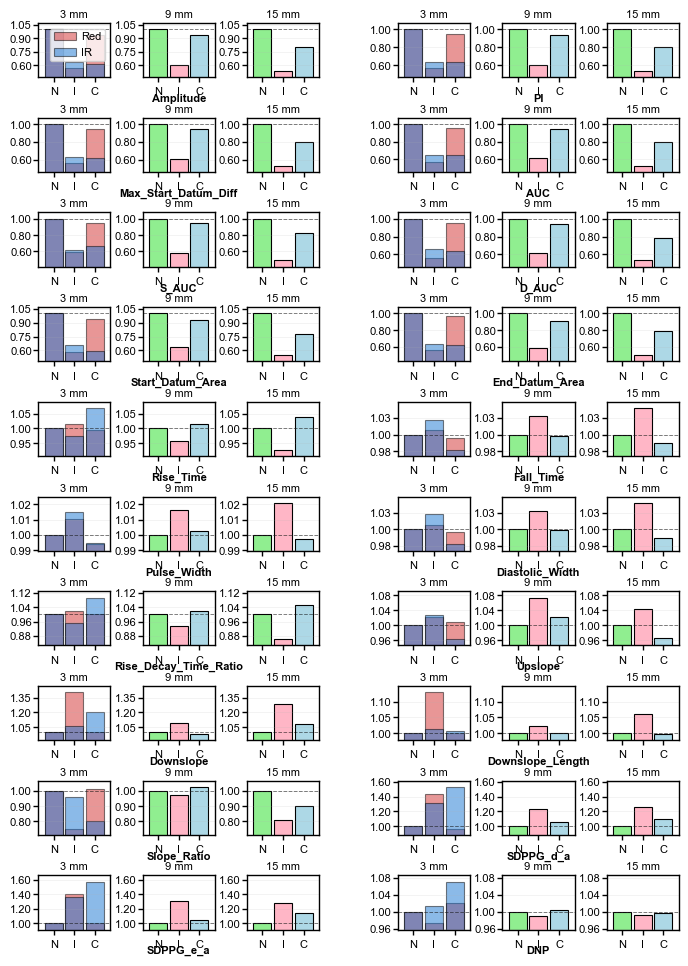

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')

# ===========================
# Sci Rep 準拠：視認性強化設定
# ===========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8           # 基本サイズを8ptに（規定の最小限）
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['xtick.labelsize'] = 8     # 7pt以下にはしない
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

plt.rcParams['lines.linewidth'] = 1.2    # 1pt以上を確保
plt.rcParams['axes.linewidth'] = 1.0    # 枠線を太くして視認性向上
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ===========================
# 対象特徴量リスト
# ===========================
TARGET_FEATURES = [
    'Amplitude', 'PI', 'Max_Start_Datum_Diff', 'AUC',
    'S_AUC', 'D_AUC', 'Start_Datum_Area', 'End_Datum_Area',
    'Rise_Time', 'Fall_Time', 'Pulse_Width', 'Diastolic_Width',
    'Rise_Decay_Time_Ratio', 'Upslope', 'Downslope', 'Downslope_Length',
    'Slope_Ratio', 'SDPPG_d_a', 'SDPPG_e_a', 'DNP'
]

OUTPUT_DIR = Path('integrated_depth_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)

# ===========================
# データ計算（関数の定義）
# ===========================
def calculate_state_means(df, features):
    state_map = {'Normal': 1, 'Ischaemia': 2, 'Congestion': 3}
    results = {}
    for feature in features:
        if feature not in df.columns: continue
        means = {}
        for state_name in state_map.keys():
            subset = df[df['State'] == state_name]
            means[state_name] = subset[feature].mean() if len(subset) > 0 else np.nan
        results[feature] = means
    return results

def resolve_input_path(relative_path):
    path = Path(relative_path)
    candidates = [path, Path.cwd() / path, Path.cwd().parent / path, Path.cwd().parent.parent / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find: {relative_path}")

def load_feature_means(relative_path):
    csv_path = resolve_input_path(relative_path)
    df = pd.read_csv(csv_path)
    return calculate_state_means(df, TARGET_FEATURES)

means_3mm_red = load_feature_means('master_features_3mm_red/master_features_3mm_Red.csv')
means_3mm_ir = load_feature_means('master_features_3mm_ir/master_features_3mm_IR.csv')
means_9mm_ir = load_feature_means('master_features_9mm_ir/master_features_9mm_IR.csv')
means_15mm_ir = load_feature_means('master_features_15mm_ir/master_features_15mm_IR.csv')

# ===========================
# 可視化レイアウト設定
# ===========================
n_features = len(TARGET_FEATURES)
n_features_per_row = 2 
n_cols = 7 
n_rows = int(np.ceil(n_features / n_features_per_row))

# Figureサイズ：ダブルカラム幅(183mm = 7.2inch) 
# 高さを1.3 -> 1.8に拡大してy軸の潰れを解消
fig_width = 7.2
fig_height = n_rows * 1.0 

fig = plt.figure(figsize=(fig_width, fig_height))

# wspaceを0.25 -> 0.45に拡大（y軸ラベルのスペース確保）
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, 
                       width_ratios=[1, 1, 1, 0.2, 1, 1, 1], 
                       wspace=0.5, hspace=0.4,
                       left=0.08, right=0.97, top=0.97, bottom=0.05)

state_colors = {'Normal': '#90EE90', 'Ischaemia': '#FFB6C6', 'Congestion': '#ADD8E6'}
color_3mm_red = '#D32F2F'
color_3mm_ir = '#1976D2'

# ===========================
# 描画ループ
# ===========================
for feat_idx, feature in enumerate(TARGET_FEATURES):
    row = feat_idx // n_features_per_row
    col_offset = 4 if (feat_idx % n_features_per_row) == 1 else 0
    
    # 各深度のグラフ用リスト
    depth_axes = []
    
    # 3mm, 9mm, 15mm のサブプロット作成
    for i, title in enumerate(["3 mm", "9 mm", "15 mm"]):
        ax = fig.add_subplot(gs[row, col_offset + i])
        ax.set_title(title, fontsize=8, pad=4)
        depth_axes.append(ax)
        
    ax_3mm, ax_9mm, ax_15mm = depth_axes
    all_values = []

    # --- 3mm 描画 ---
    x_pos = np.array([0, 0.4, 0.8])
    bar_w = 0.35 # 少し太くして視認性アップ
    
    # Red & IR for 3mm
    for color, m_data, lbl in zip([color_3mm_red, color_3mm_ir], [means_3mm_red, means_3mm_ir], ['Red', 'IR']):
        if feature in m_data:
            ref = m_data[feature].get('Normal', np.nan)
            if not np.isnan(ref) and abs(ref) > 1e-10:
                vals = [1.0, m_data[feature].get('Ischaemia', 0)/ref, m_data[feature].get('Congestion', 0)/ref]
                ax_3mm.bar(x_pos, vals, color=color, alpha=0.5, edgecolor='black', linewidth=0.8, width=bar_w, label=lbl)
                all_values.extend(vals)

    # --- 9mm / 15mm 描画 ---
    for ax, m_data in zip([ax_9mm, ax_15mm], [means_9mm_ir, means_15mm_ir]):
        if feature in m_data:
            ref = m_data[feature].get('Normal', np.nan)
            if not np.isnan(ref) and abs(ref) > 1e-10:
                vals = [1.0, m_data[feature].get('Ischaemia', 0)/ref, m_data[feature].get('Congestion', 0)/ref]
                colors = [state_colors['Normal'], state_colors['Ischaemia'], state_colors['Congestion']]
                ax.bar(x_pos, vals, color=colors, edgecolor='black', linewidth=0.8, width=bar_w)
                all_values.extend(vals)

    # --- 軸の微調整（全グラフ共通） ---
    for ax in depth_axes:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['N', 'I', 'C'], fontsize=8)
        ax.grid(axis='y', alpha=0.2, linewidth=0.5)
        ax.set_xlim(-0.3, 1.1)
        # y軸の目盛り数を制限して重なりを防止
        from matplotlib.ticker import FormatStrFormatter # (ファイルの冒頭に追記)
        ax.tick_params(axis='y', pad=1)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

    # --- 動的Y軸範囲 ---
    if all_values:
        v_min, v_max = min(all_values), max(all_values)
        margin = (v_max - v_min) * 0.15
        ax_3mm.set_ylim(max(0, v_min - margin), v_max + margin)
        # 3mmの範囲を他の深度にも適用（比較のため）
        ax_9mm.set_ylim(ax_3mm.get_ylim())
        ax_15mm.set_ylim(ax_3mm.get_ylim())
        
    for ax in [ax_3mm, ax_9mm, ax_15mm]:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])

    # --- 特徴量ラベル（中央のグラフの下） ---
    ax_9mm.text(0.5, -0.30, feature, transform=ax_9mm.transAxes,
               fontsize=8, ha='center', va='top', weight='bold')

    if row == 0 and col_offset == 0:
        ax_3mm.legend(loc='upper right', frameon=True, borderpad=0.3, handletextpad=0.5)

# 保存設定
save_params = {'dpi': 600, 'bbox_inches': 'tight'}
plt.savefig(OUTPUT_DIR / 'feature_comparison_final.tiff', format='tiff', pil_kwargs={'compression': 'tiff_lzw'}, **save_params)
plt.savefig(OUTPUT_DIR / 'feature_comparison_final.pdf', format='pdf', **save_params)

plt.show()